In [73]:
import os
import zipfile
import shutil
import io
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

### --- NEDS FURTHER IMPROVEMENT (IGNORE FOR NOW) ---- [START]

#### Mimic the POI data point extraction to find out how this was done for: https://arxiv.org/pdf/2506.00765

In [2]:
# from ohsome import OhsomeClient
# import pandas as pd, numpy as np, time, os, math, json
# from geopy.geocoders import Nominatim
# from geopy.extra.rate_limiter import RateLimiter
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from datetime import datetime
# from typing import Dict, Tuple, List

# # ---------- Config ----------
# ZIP_CODES = ["10002", "70302"]  # replace with your list
# YEAR_FROM, YEAR_TO = 2017, 2018
# BASE_URL = "https://api.ohsome.org/v1"   # or your local ohsome
# MAX_WORKERS = 8                          # be polite; 2–4 is usually safe
# SLEEP_BETWEEN_CALLS = 0.25               # seconds between API calls
# OUT_DIR = "poi_out"                      # per-ZIP outputs here

# POI_FILTERS = {
#     "bank":        "amenity=bank",
#     "bus":         "highway=bus_stop OR (public_transport=platform AND bus=yes)",
#     "hospital":    "amenity=hospital OR amenity=clinic",
#     "mall":        "shop=mall OR landuse=retail",
#     "park":        "leisure=park OR boundary=national_park OR landuse=grass",
#     "restaurant":  "amenity=restaurant OR amenity=fast_food OR amenity=cafe",
#     "school":      "amenity=school OR amenity=college OR amenity=university",
#     "station":     "railway=station OR public_transport=station",
#     "supermarket": "shop=supermarket OR amenity=marketplace",
# }

# os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# def already_done(zip_code: str) -> bool:
#     return os.path.exists(os.path.join(OUT_DIR, f"{zip_code}_poi_counts_monthly.csv"))

# def process_zip(zip_code: str) -> Tuple[str, str]:
#     """
#     Worker: fetch, save per-ZIP CSV (raw). Returns (zip, status).
#     Per-ZIP write lets you resume without redoing finished ZIPs.
#     """
#     try:
#         if already_done(zip_code):
#             return (zip_code, "skipped (exists)")
#         df = collect_zip_monthly_pois(zip_code)
#         # Save per-ZIP raw (month index → column)
#         out = df.reset_index(names="month")
#         out.to_csv(os.path.join(OUT_DIR, f"{zip_code}_poi_counts_monthly.csv"), index=False)
#         return (zip_code, "ok")
#     except Exception as e:
#         return (zip_code, f"error: {e}")

# def build_poi_panel_parallel(zip_codes=ZIP_CODES, max_workers=MAX_WORKERS) -> Tuple[pd.DataFrame, pd.DataFrame]:
#     """
#     Runs ZIPs in parallel, then merges all per-ZIP CSVs, applies global imputation + log1p,
#     and writes panel CSVs.
#     """
#     # 1) Parallel per-ZIP fetch → impute-within → save
#     todo = [z for z in zip_codes if not already_done(z)]
#     if todo:
#         with ThreadPoolExecutor(max_workers=max_workers) as ex:
#             futures = {ex.submit(process_zip, z): z for z in todo}
#             for f in as_completed(futures):
#                 z = futures[f]
#                 status = f.result()
#                 print(status)

#     # 2) Merge all per-ZIP CSVs
#     frames = []
#     for z in zip_codes:
#         p = os.path.join(OUT_DIR, f"{z}_poi_counts_monthly.csv")
#         if not os.path.exists(p):
#             raise FileNotFoundError(f"Missing expected per-ZIP CSV for {z}: {p}")
#         frames.append(pd.read_csv(p, parse_dates=["month"]))
#     panel = pd.concat(frames, ignore_index=True).sort_values(["zip", "month"])

#     # 3) Global imputation + log
#     panel_log = log_transform(panel)

#     # 4) Save combined panels
#     panel.to_csv(os.path.join(OUT_DIR, "poi_counts_monthly_panel.csv"), index=False)
#     panel_log.to_csv(os.path.join(OUT_DIR, "poi_counts_monthly_panel_log.csv"), index=False)
#     return panel, panel_log


# # -------------------------------
# # UTILITIES
# # -------------------------------

# def geocode_zip_bbox(zip_code: str, country="USA", pause=1.0) -> List[float]:
#     """Nominatim → bbox as [minLon, minLat, maxLon, maxLat]. Cache results to avoid re-geocoding."""
#     cache_path = os.path.join(OUT_DIR, "bbox_cache.json")
#     cache = {}
#     if os.path.exists(cache_path):
#         try:
#             cache = json.load(open(cache_path, "r"))
#         except Exception:
#             cache = {}
#     if zip_code in cache:
#         return cache[zip_code]

#     geolocator = Nominatim(user_agent="poi-pipeline-ohsomepy", timeout=10)
#     rate = RateLimiter(geolocator.geocode, min_delay_seconds=pause, max_retries=3, error_wait_seconds=2)
#     loc = rate(f"{zip_code}, {country}", addressdetails=True, exactly_one=True)
#     if not loc or "boundingbox" not in getattr(loc, "raw", {}):
#         raise ValueError(f"Could not geocode ZIP: {zip_code}")
#     south, north, west, east = map(float, loc.raw["boundingbox"])
#     bbox = [west, south, east, north]
#     cache[zip_code] = bbox
#     with open(cache_path, "w") as f:
#         json.dump(cache, f)
#     return bbox

# def year_interval(y: int) -> str:
#     return f"{y}-01-01/{y}-12-31/P1M"  # monthly buckets

# def backoff_sleep(attempt: int):
#     # 0, 1, 2, 3, 4 → 0.5s, 1s, 2s, 4s, 8s (capped)
#     time.sleep(min(0.5 * (2 ** attempt), 8.0))

# def fetch_series_for_filter(client: OhsomeClient, bbox: List[float], filter_expr: str,
#                             year_from=YEAR_FROM, year_to=YEAR_TO,
#                             pause=SLEEP_BETWEEN_CALLS,
#                             max_retries=5) -> pd.Series:
#     """Hits /elements/count/series year-by-year; returns a monthly Series."""
#     pieces = []
#     for y in range(year_from, year_to + 1):
#         time_param = year_interval(y)
#         attempt = 0
#         while True:
#             try:
#                 resp = client.post(
#                     endpoint="elements/count/series",
#                     bboxes=bbox,      # [minLon, minLat, maxLon, maxLat]
#                     time=time_param,
#                     filter=filter_expr,
#                 )
#                 df = resp.as_dataframe()  # columns: timestamp, value
#                 s = pd.Series(
#                     df["value"].to_numpy(),
#                     index=pd.to_datetime(df["timestamp"]).tz_localize(None),
#                     dtype="float",
#                 ).asfreq("MS")
#                 pieces.append(s)
#                 time.sleep(pause)
#                 break
#             except Exception as e:
#                 if attempt >= max_retries:
#                     raise RuntimeError(f"Failed fetching {filter_expr} for {y}: {e}") from e
#                 backoff_sleep(attempt)
#                 attempt += 1
#                 continue
#     if not pieces:
#         return pd.Series(dtype="float")
#     out = pd.concat(pieces).sort_index()
#     return out[~out.index.duplicated(keep="first")]

# def collect_zip_monthly_pois(zip_code: str) -> pd.DataFrame:
#     """Collect all categories for one ZIP (with its own OhsomeClient)."""
#     bbox = geocode_zip_bbox(zip_code)
#     client = OhsomeClient(base_api_url=BASE_URL)  # new client per worker
#     cols = []
#     for cat, filt in POI_FILTERS.items():
#         s = fetch_series_for_filter(client, bbox, filt)
#         s.name = cat
#         cols.append(s)
#     df = pd.concat(cols, axis=1).sort_index()
#     df.insert(0, "zip", zip_code)
#     return df

# def log_transform(panel: pd.DataFrame) -> pd.DataFrame:
#     num_cols = [c for c in panel.columns if c not in ("month", "zip")]
#     out = panel.copy()
#     out[num_cols] = np.log1p(out[num_cols].astype(float))
#     return out

### --- NEDS FURTHER IMPROVEMENT (IGNORE FOR NOW) ---- [END]

## Phase 1: DATA CONSOLIDATION

#### All data used in the notebook is available here: https://drive.google.com/drive/u/0/folders/1ZgleIVQA1DCjL9jLYYzu-wREmGmenMJN

The houseTS Data is a large file and hence it's not feasible to store it in GitHub

### Zillow Data

    Zillow Observed Rent Index (ZORI): A monthly ZIP-level rent index that tracks typical market rents using a repeat-rent methodology. It’s smoothed, weighted to the housing stock, and focuses on mid-market rents (35th–65th percentile) for representativeness.

In [31]:
# Pull in Zillow data
zillow_zori = pd.read_csv("/Users/karanveer_lamba/Desktop/MIDS_CAPSTONE_PROJECT/RentIQ/EDA/Datasets/Zillow/zillow_rental_data.csv")

In [32]:
# Zillow data for NYC
zillow_ny = zillow_zori[zillow_zori['State']=='NY']

In [33]:
# Select relvevant columns
zillow_cols = ['RegionName', 'City', 'CountyName'] + list(zillow_ny.columns[33:117])
zillow_ny = zillow_ny[zillow_cols]

# Rename the zip column
zillow_ny = zillow_ny.rename(columns={"RegionName" : "zipcode"})

# Keep only non-null values from 2017-2023 (consistent with the range of HouseTS data)
zillow_ny = zillow_ny[zillow_ny['2017-01-31'].notna()].reset_index(drop=True)

In [34]:
# Convert wide data to long data
zillow_long = zillow_ny.melt(
    id_vars=["zipcode", "City", "CountyName"],      # Keep ZipCode fixed
    var_name="date",          # Column name for former date-columns
    value_name="median_rent"         # Column name for values
)

# Convert Date column to datetime type
zillow_long["date"] = pd.to_datetime(zillow_long["date"])

In [35]:
zillow_long = zillow_long.rename(columns={'City' : 'city',
                                          'CountyName' : 'county'})

In [36]:
# Create a list of NYC zip codes
zillow_zips = zillow_long['zipcode'].unique().tolist()

### HouseTS Dataset

    A multimodal housing dataset (2012–2023) covering ~6,000 ZIP codes in 30 U.S. metros. It combines monthly housing indicators, socioeconomic measures, and neighborhood amenities (POIs) to capture affordability in full economic and social context

In [11]:
# Pull data HouseTS Dataset
house_data = pd.read_csv("/Users/karanveer_lamba/Desktop/MIDS_CAPSTONE_PROJECT/RentIQ/EDA/Datasets/HouseTS/HouseTS.csv")

In [12]:
# Look at the shape
house_data.shape

(884092, 39)

In [13]:
# What features are available
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884092 entries, 0 to 884091
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date                          884092 non-null  object 
 1   median_sale_price             884092 non-null  float64
 2   median_list_price             884092 non-null  float64
 3   median_ppsf                   884092 non-null  float64
 4   median_list_ppsf              884092 non-null  float64
 5   homes_sold                    884092 non-null  float64
 6   pending_sales                 884092 non-null  float64
 7   new_listings                  884092 non-null  float64
 8   inventory                     884092 non-null  float64
 9   median_dom                    884092 non-null  float64
 10  avg_sale_to_list              884092 non-null  float64
 11  sold_above_list               884092 non-null  float64
 12  off_market_in_two_weeks       884092 non-nul

In [14]:
# View dataframe head
house_data.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta
1,2012-04-30,61870.0,245000.0,40.723982,130.528256,22.0,29.0,56.0,69.0,89.5,0.946642,0.090909,0.034483,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202421.064584,Atlanta-Sandy Springs-Alpharetta
2,2012-05-31,125500.0,217450.0,63.913043,119.919216,24.0,40.0,63.0,60.0,144.5,0.955624,0.208333,0.100000,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202681.309539,Atlanta-Sandy Springs-Alpharetta
3,2012-06-30,153000.0,189900.0,81.598080,105.617353,34.0,46.0,50.0,57.0,126.0,0.970608,0.176471,0.108696,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202998.603897,Atlanta-Sandy Springs-Alpharetta
4,2012-07-31,165500.0,154000.0,81.598080,83.921175,39.0,49.0,42.0,50.0,80.0,0.982105,0.256410,0.102041,ATL,30002,2012,12.0,2.0,3.0,1.0,60.0,45.0,57.0,4.0,6.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,203781.903446,Atlanta-Sandy Springs-Alpharetta


In [15]:
# Convert the date column to datetime object
house_data['date'] = pd.to_datetime(house_data['date'])

In [16]:
# Filter the TS data to records that exist in the Zillow dataset
house_data_nyc = house_data[house_data['city']=='NY']

In [17]:
# Filter the data to start from 2017
house_data_nyc = house_data_nyc[house_data_nyc['date'] >= pd.to_datetime('2017-01-01')].reset_index(drop=True)

In [18]:
# Retain only the zipcodes that are in the zillow rentals dataset
house_data_nyc = house_data_nyc[house_data_nyc['zipcode'].isin(zillow_zips)]

### Merge the two datasets

In [22]:
house_data_nyc = house_data_nyc.merge(
    right=zillow_long,
    how='left',
    on=['zipcode', 'date'],
    suffixes=("_ts", "_zlw")
)

In [23]:
house_data_nyc.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city_ts,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,city_zlw,county,median_rent
0,2017-01-31,1750000.0,4135000.0,1247.500000,2585.751979,17.0,17.0,86.0,252.0,161.0,0.978486,0.000000,0.000000,NY,10001,2017,258.0,8.0,56.0,10.0,515.0,1450.0,385.0,174.0,135.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.670502e+06,New York-Newark-Jersey City,New York,New York County,3922.292665
1,2017-02-28,2015000.0,4600000.0,1444.801541,2748.473071,12.0,12.0,89.0,264.0,132.0,0.979087,0.000000,0.000000,NY,10001,2017,259.0,8.0,56.0,10.0,511.0,1468.0,387.0,175.0,142.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.689583e+06,New York-Newark-Jersey City,New York,New York County,3863.891996
2,2017-03-31,1275000.0,3825000.0,1448.087432,2517.513135,15.0,12.0,99.0,276.0,141.0,0.984734,0.000000,0.000000,NY,10001,2017,259.0,9.0,56.0,10.0,510.0,1495.0,387.0,172.0,146.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.688465e+06,New York-Newark-Jersey City,New York,New York County,3873.435091
3,2017-04-30,1512500.0,2675000.0,1372.288623,2176.148047,14.0,13.0,67.0,264.0,165.0,0.996564,0.142857,0.076923,NY,10001,2017,260.0,9.0,54.0,12.0,508.0,1534.0,386.0,172.0,151.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.696703e+06,New York-Newark-Jersey City,New York,New York County,3891.172482
4,2017-05-31,1300000.0,2600000.0,1451.394082,1975.308642,27.0,25.0,65.0,251.0,166.5,0.984016,0.074074,0.040000,NY,10001,2017,265.0,9.0,54.0,12.0,508.0,1584.0,385.0,172.0,152.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.681455e+06,New York-Newark-Jersey City,New York,New York County,3957.284734


## Phase 2: DATA EDA
    
    Plot Variables to understand data point distribution and relationships

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [121]:
# Since we will be plotting correlations alot, let's define a function for it
def plot_corr(corr_df):
    plt.figure(figsize=(10,6))
    ax = sns.heatmap(corr_df, annot=False, cmap="coolwarm")

    # Manually add text
    for i in range(len(corr_df)):
        for j in range(len(corr)):
            ax.text(j+0.5, i+0.5, f"{corr.iloc[i,j]:.2f}",
                    ha="center", va="center", color="black", fontsize=10)
            
    plt.show()

In [37]:
# Let's create new dataframe names for the EDA
house_df = house_data_nyc.copy()
zillow_df = zillow_long.copy()

### Time Coverage and Granularity

    - Verify both datasets align in time frequency (monthly) and geographic unit (ZIP).

    - Ensure overlapping periods for merging.

In [39]:
print("HouseTS:", house_df.date.min(), "to", house_df.date.max())
print("Zillow:", zillow_df.date.min(), "to", zillow_df.date.max())

house_df['year_month'] = house_df['date'].dt.to_period('M')
zillow_df['year_month'] = zillow_df['date'].dt.to_period('M')

HouseTS: 2017-01-31 00:00:00 to 2023-12-31 00:00:00
Zillow: 2017-01-31 00:00:00 to 2023-12-31 00:00:00


### Rent Trends (Target Variable Exploration)

    - Since affordability depends strongly on rent, start with exploring median rent.

/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


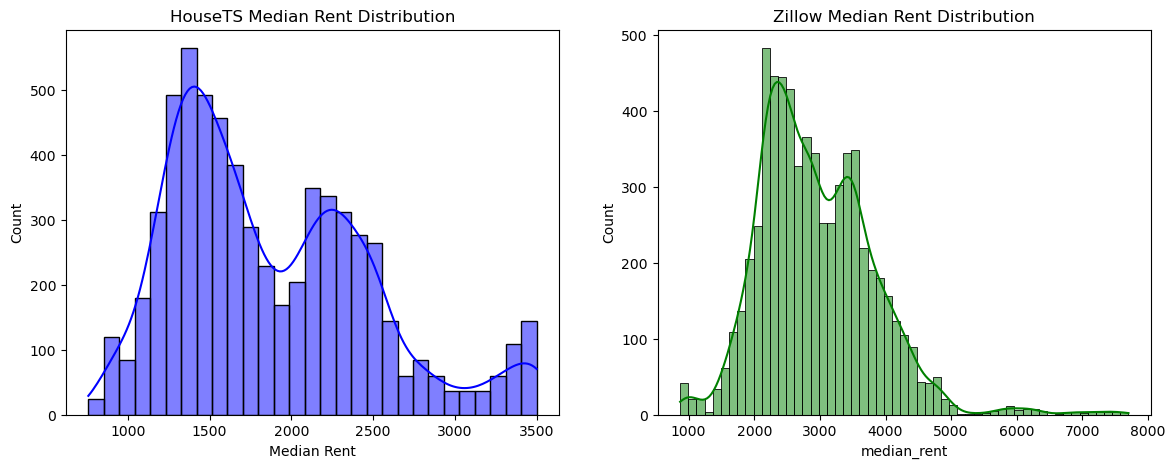

In [43]:
# Compare median rent distribution across datasets
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.histplot(house_df['Median Rent'].dropna(), kde=True, ax=ax[0], color="blue")
ax[0].set_title("HouseTS Median Rent Distribution")

sns.histplot(zillow_df['median_rent'].dropna(), kde=True, ax=ax[1], color="green")
ax[1].set_title("Zillow Median Rent Distribution")
plt.show()

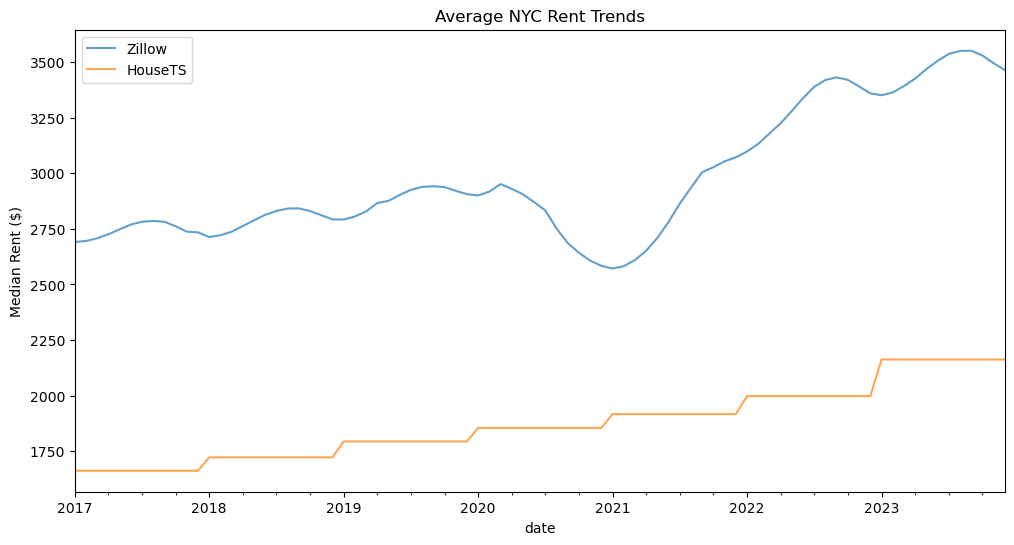

In [44]:
# NYC focus (filter city_full = New York... or county subset)
ny_house = house_df[house_df['city_full'].str.contains("New York")]
ny_zillow = zillow_df[zillow_df['city']=="New York"]

# Trend over time
plt.figure(figsize=(12,6))
ny_zillow.groupby("date")['median_rent'].mean().plot(label="Zillow", alpha=0.7)
ny_house.groupby("date")['Median Rent'].mean().plot(label="HouseTS", alpha=0.7)
plt.legend()
plt.title("Average NYC Rent Trends")
plt.ylabel("Median Rent ($)")
plt.show()

### Plot median rents by county

/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

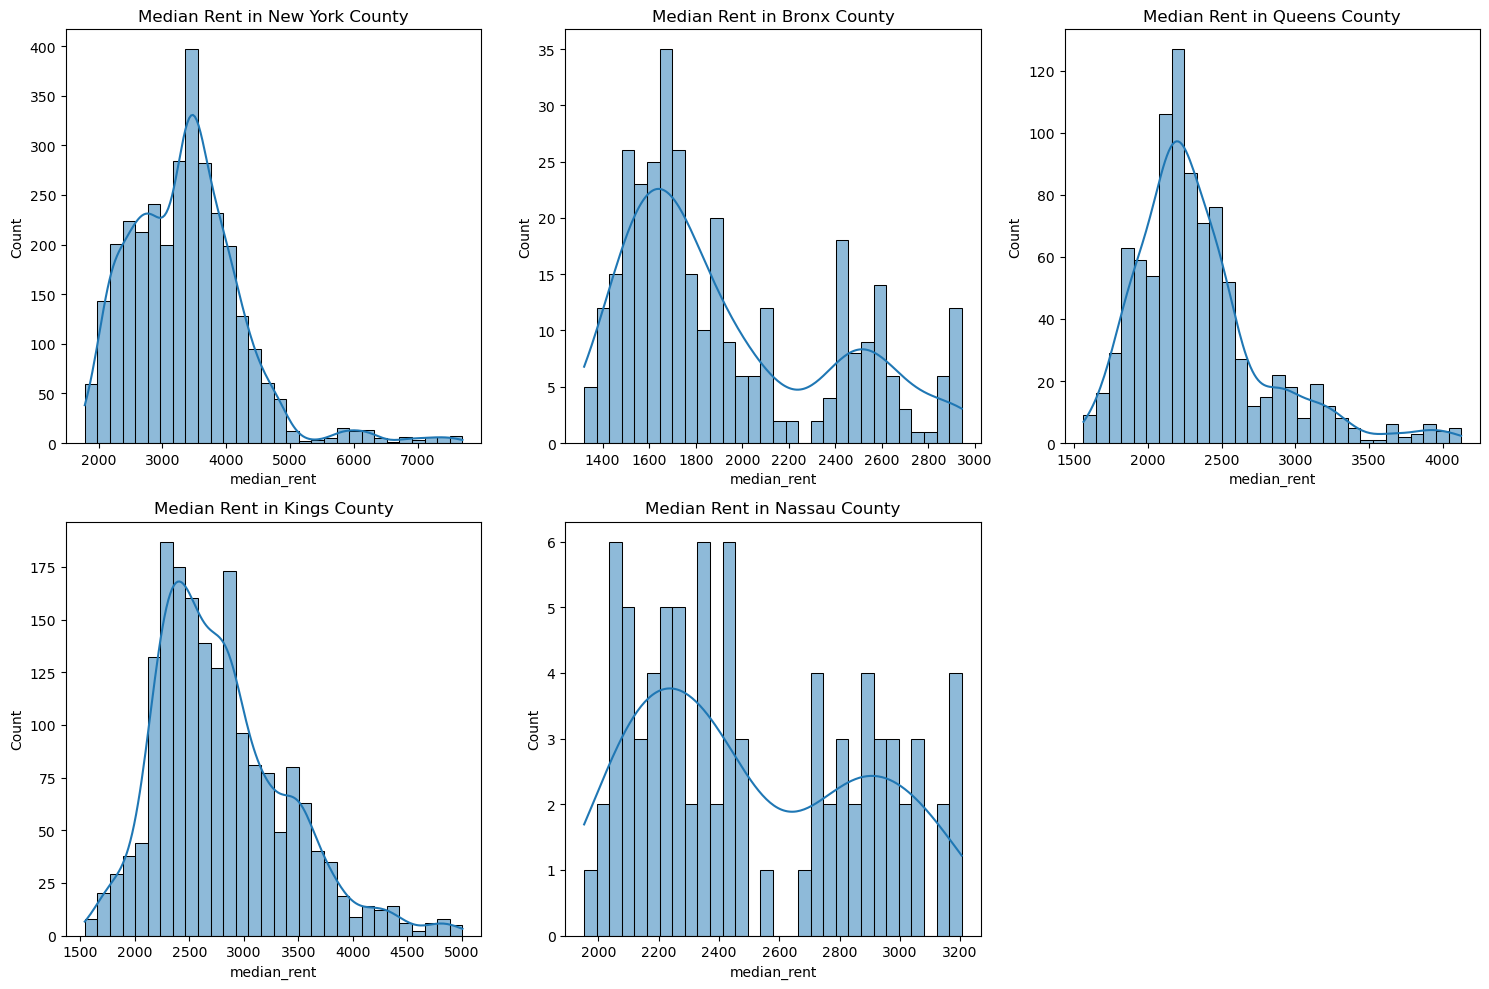

In [67]:
county_list = house_data_nyc['county'].unique().tolist()

# Decide number of rows and columns
n = len(county_list)
ncols = 3   # you can change depending on how many per row you want
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
axes = axes.flatten()  # flatten to 1D for easy indexing

for i, county in enumerate(county_list):
    ax = axes[i]
    sns.histplot(
        data=house_data_nyc[house_data_nyc['county'] == county],
        x="median_rent", bins=30, kde=True, ax=ax
    )
    ax.set_title(f"Median Rent in {county}")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [69]:
# Box Plot

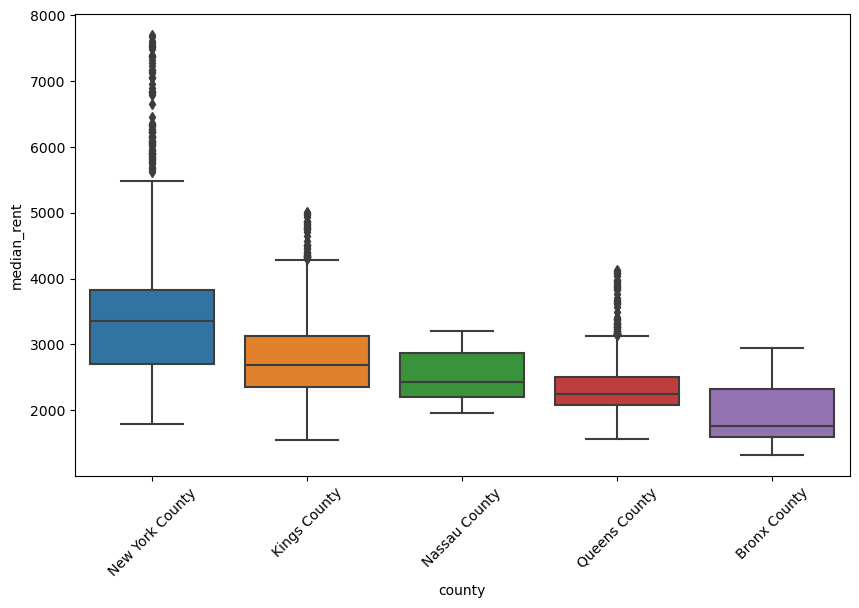

In [71]:
order = house_data_nyc.groupby("county")["median_rent"].median().sort_values(ascending=False).index
plt.figure(figsize=(10,6))
sns.boxplot(data=house_data_nyc, x="county", y="median_rent", order=order)
plt.xticks(rotation=45)
plt.show()

/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_54810/2233711122.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["median_rent"], weights=x[weight_col]))


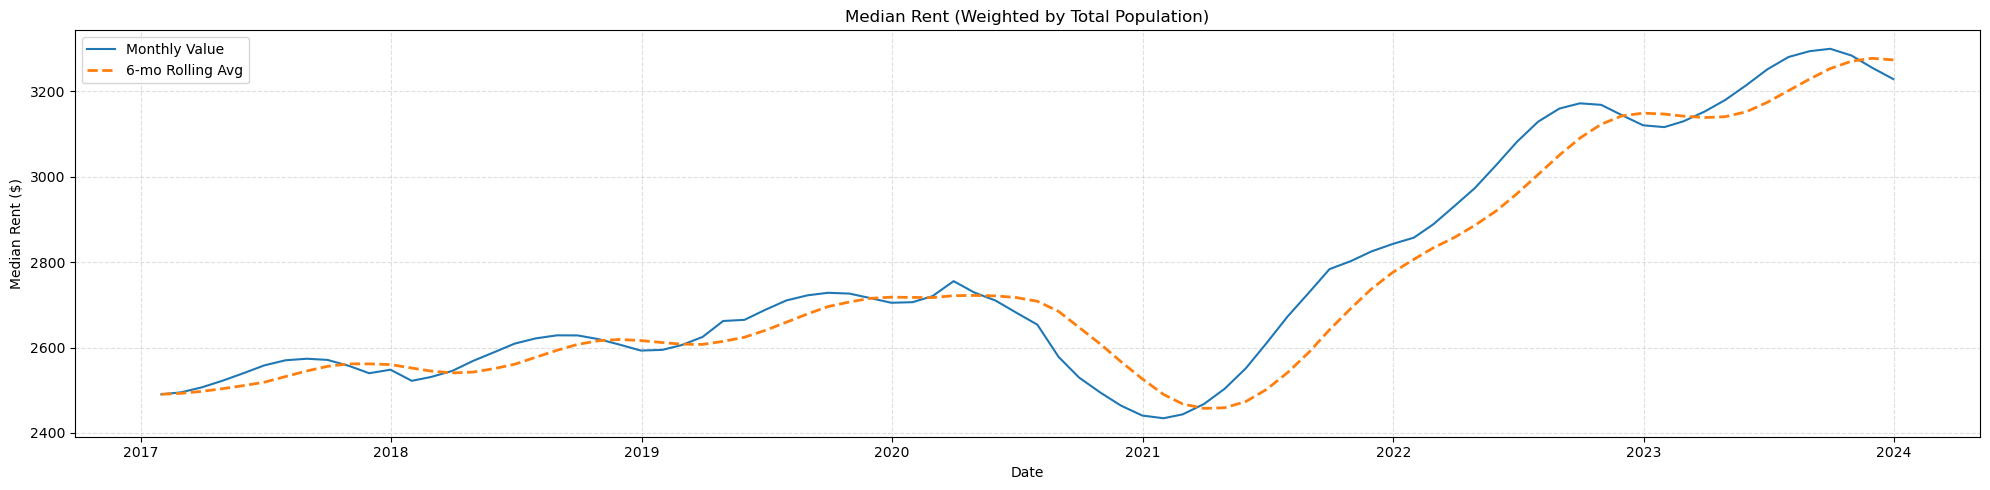

,date,rent,rent_smooth
0,2017-01-31,2490.632373,2490.632373
1,2017-02-28,2494.970354,2492.801364
2,2017-03-31,2506.872173,2497.491634
3,2017-04-30,2522.322325,2503.699306
4,2017-05-31,2540.183360,2510.996117
...,...,...,...
79,2023-08-31,3294.493370,3229.284855
80,2023-09-30,3300.025119,3253.764195
81,2023-10-31,3284.232133,3271.083209
82,2023-11-30,3255.675827,3277.815488


In [75]:
## What does the median weighted rent look like? (write a function to keep the weighting variable flexible)

def plot_weighted_rent(df, weight_col=None, rolling_window=3, agg="mean"):
    """
    Plot national median rent over time with optional weighting.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ['date', 'median_rent'] and optionally a weight_col.
    weight_col : str or None
        Column to use as weights (e.g., 'Total Housing Units', 'Total Population').
        If None, uses simple aggregation (median or mean).
    rolling_window : int
        Window size for rolling average smoothing (set to 0 to skip).
    agg : str
        Aggregation method if no weights: 'median' or 'mean'.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    if weight_col:
        # Weighted average: sum(w * rent) / sum(w)
        ts = (
            df.dropna(subset=["median_rent", weight_col])
              .groupby("date")
              .apply(lambda x: np.average(x["median_rent"], weights=x[weight_col]))
              .rename("rent")
              .reset_index()
        )
        title = f"Median Rent (Weighted by {weight_col})"
    else:
        # Simple median or mean of ZIP-level rents
        if agg == "median":
            ts = df.groupby("date")["median_rent"].median().rename("rent").reset_index()
            title = "National Median Rent (Median of ZIP Medians)"
        elif agg == "mean":
            ts = df.groupby("date")["median_rent"].mean().rename("rent").reset_index()
            title = "National Median Rent (Mean of ZIP Medians)"
        else:
            raise ValueError("agg must be 'median' or 'mean' when weight_col=None")

    # Optional smoothing
    if rolling_window > 0:
        ts["rent_smooth"] = ts["rent"].rolling(rolling_window, min_periods=1).mean()
    else:
        ts["rent_smooth"] = ts["rent"]

    # Plot
    plt.figure(figsize=(20,5))
    plt.plot(ts["date"], ts["rent"], label="Monthly Value", linewidth=1.5)
    if rolling_window > 0:
        plt.plot(ts["date"], ts["rent_smooth"], label=f"{rolling_window}-mo Rolling Avg", linestyle="--", linewidth=2)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Median Rent ($)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return ts

# Weighted by population
plot_weighted_rent(house_data_nyc, weight_col="Total Population", rolling_window=6)

### Housing Market Indicators

    - Explore features related to supply & demand:

    - Inventory vs. Median Rent

    - Homes sold, pending sales vs. Rent

    - Days on Market vs. Rent

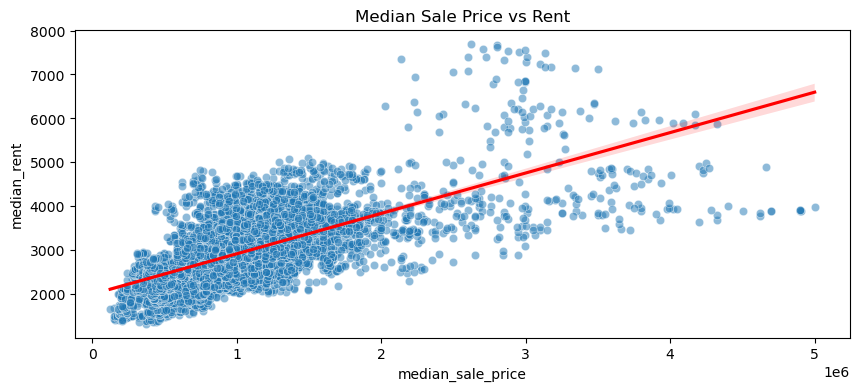

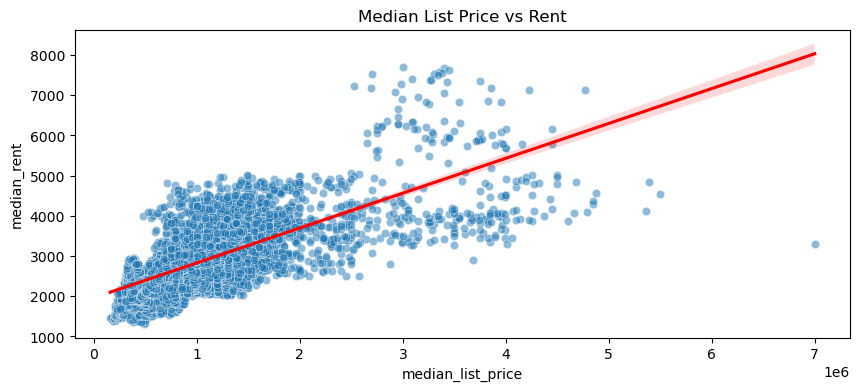

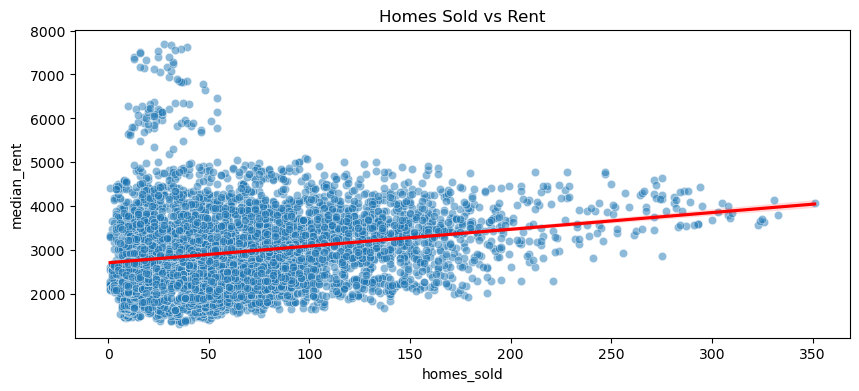

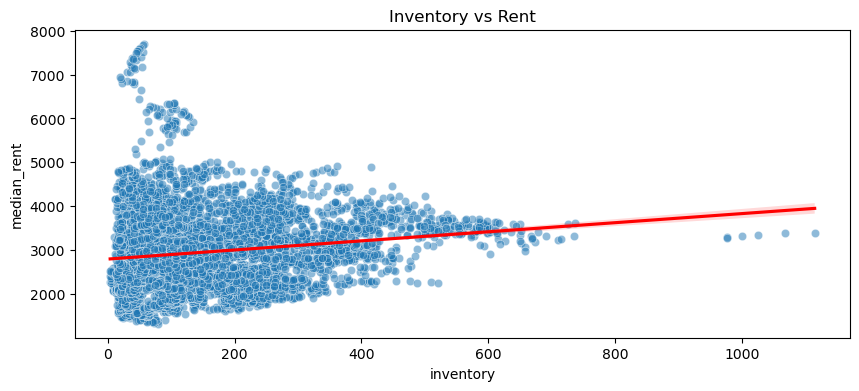

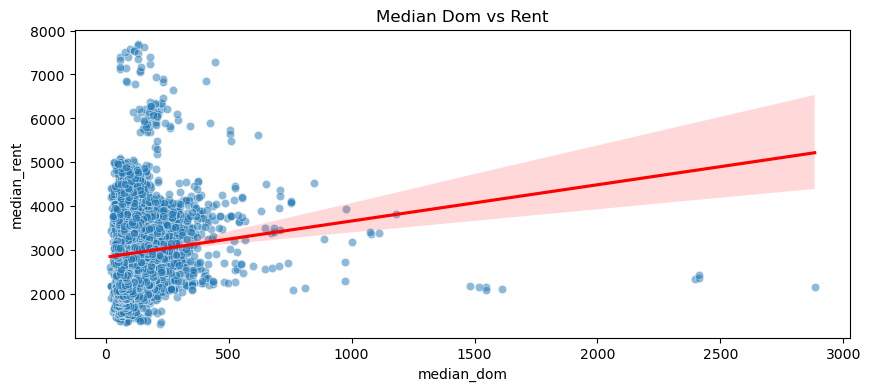

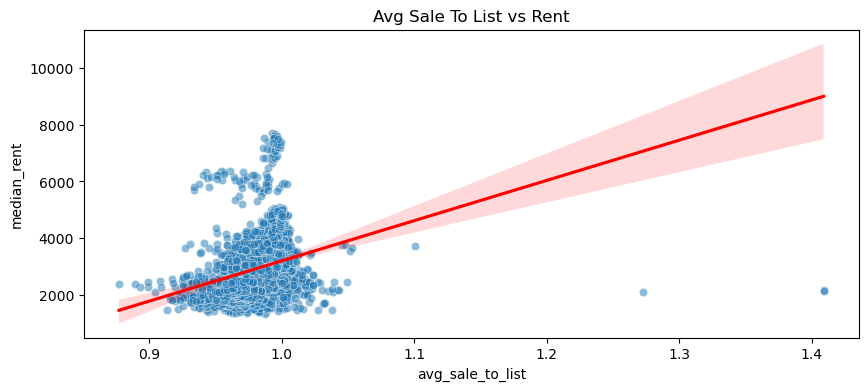

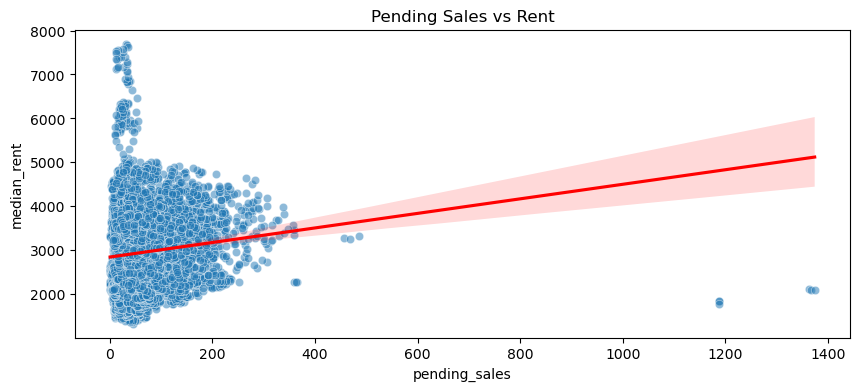

In [58]:
housing_indicators = ['median_sale_price', 'median_list_price', 
                      'homes_sold', 'inventory', 'median_dom', 'avg_sale_to_list', 
                      'pending_sales', 'new_listings']

# Convert to title case
title_case_columns = [col.replace('_', ' ').title() for col in housing_indicators]

# Plot data
for ix in range(0, len(housing_indicators)-1):
    plt.figure(figsize=(10,4))
    sns.scatterplot(data=ny_house, x=housing_indicators[ix], y="median_rent", alpha=0.5)
    sns.regplot(x=housing_indicators[ix], y="median_rent", data=house_df, scatter=False, color="red")
    plt.title(f"{title_case_columns[ix]} vs Rent")
    plt.show()

### Calculate correlations:

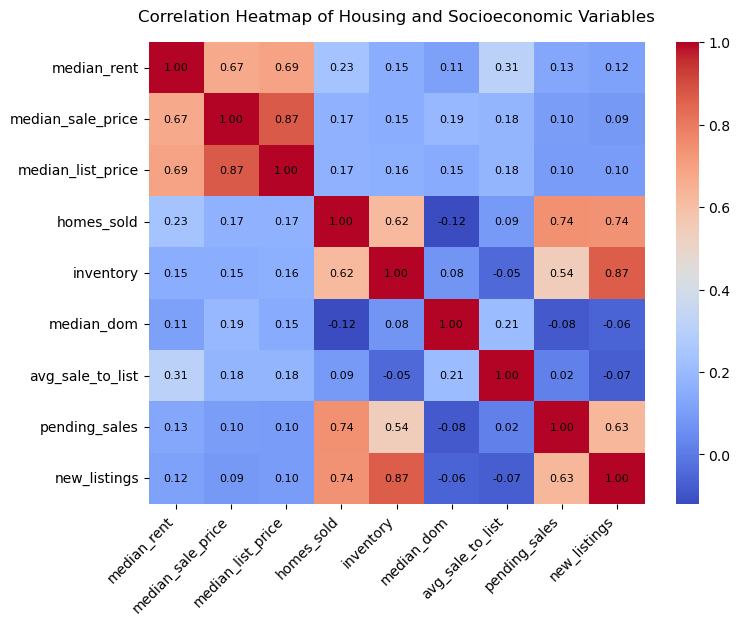

In [62]:
corr = ny_house[['median_rent'] + housing_indicators].corr()

# Figure size
plt.figure(figsize=(8,6))
# Plot heatmap
ax = sns.heatmap(corr, annot=False, cmap="coolwarm")

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Manually add text
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j+0.5, i+0.5, f"{corr.iloc[i,j]:.2f}",
                ha="center", va="center", color="black", fontsize=8)
        
# Add title
plt.title("Correlation Heatmap of Housing and Socioeconomic Variables", pad=15)

plt.show()

### Socioeconomic Factors

    - Check how income, poverty, and labor force relate to rent.

/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

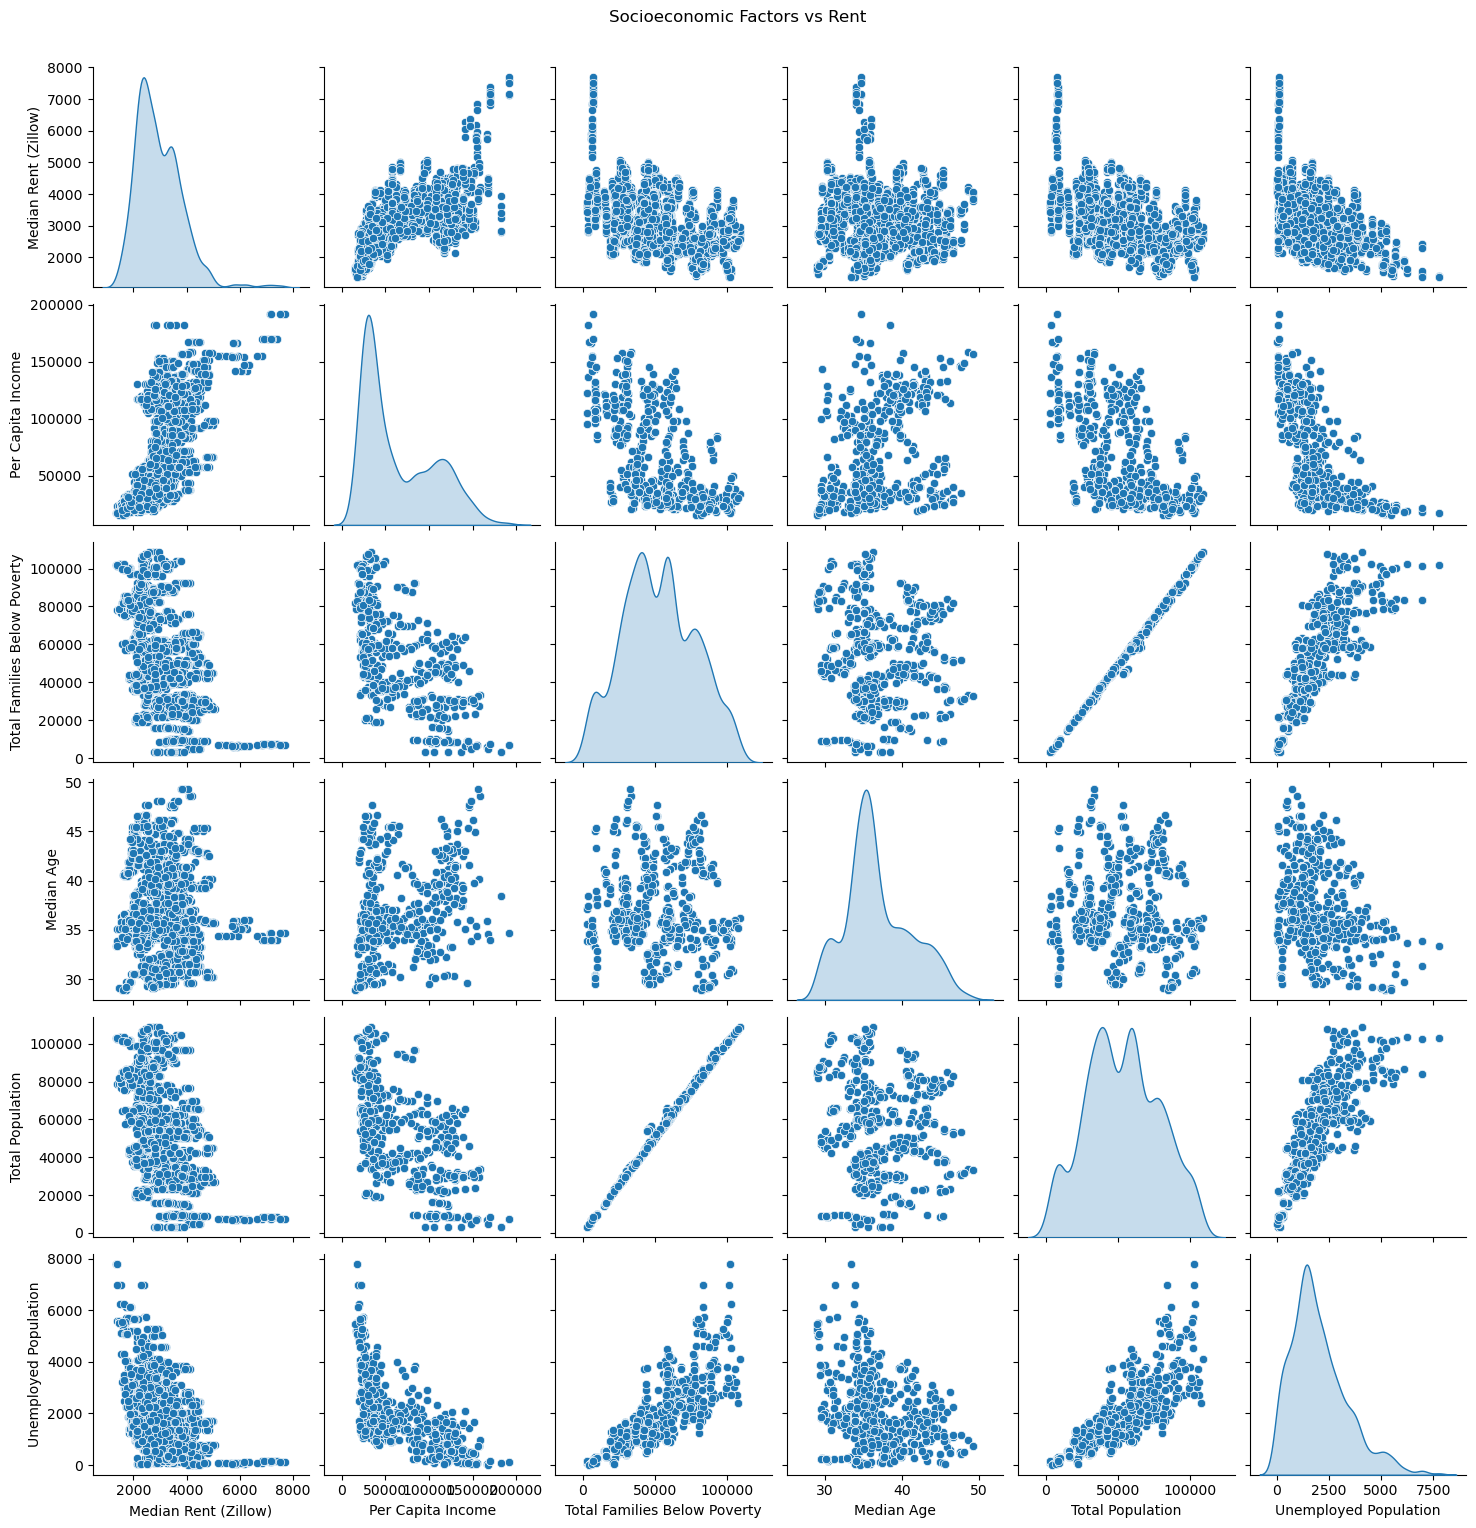

In [95]:
# Create a dataset copy for plotting socio-economic variables
socio_data = house_data_nyc.copy()

# Rename column
socio_data = socio_data.rename(columns={"median_rent": "Median Rent (Zillow)"})

features = ['Median Rent (Zillow)', 'Per Capita Income', 'Total Families Below Poverty',
            'Median Age', 'Total Population', 'Unemployed Population']

sns.pairplot(socio_data[features].sample(3000), diag_kind="kde")
plt.suptitle("Socioeconomic Factors vs Rent", y=1.02)
plt.show()

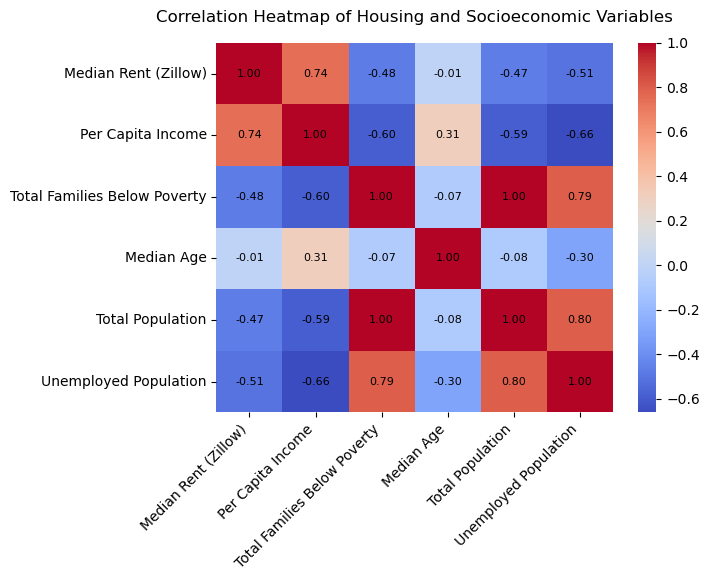

In [96]:
# Compute correlation
corr = socio_data[features].corr()

# Plot heatmap
ax = sns.heatmap(corr, annot=False, cmap="coolwarm")

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Manually add text
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j+0.5, i+0.5, f"{corr.iloc[i,j]:.2f}",
                ha="center", va="center", color="black", fontsize=8)
        
# Add title
plt.title("Correlation Heatmap of Housing and Socioeconomic Variables", pad=15)

plt.show()

### Amenities & Accessibility

    POIs such as restaurants, stations, supermarkets can influence rent.

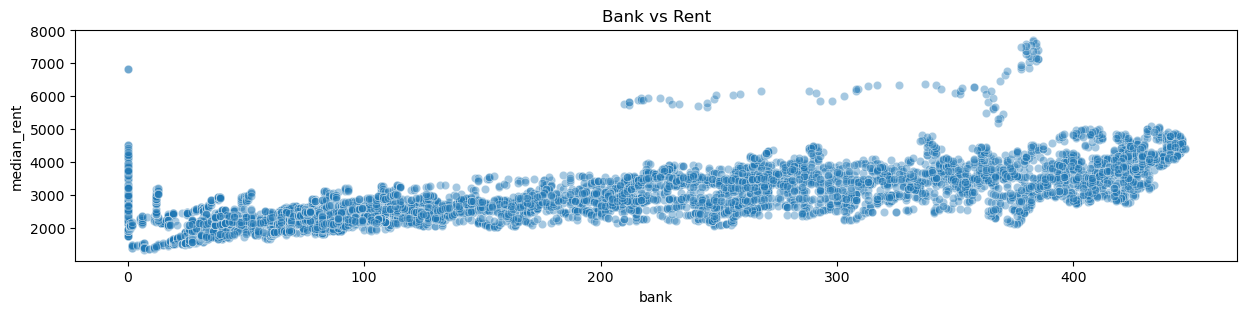

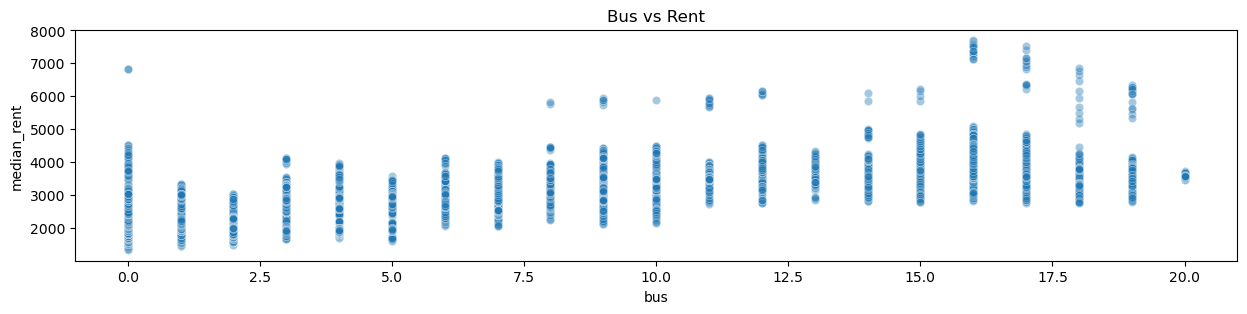

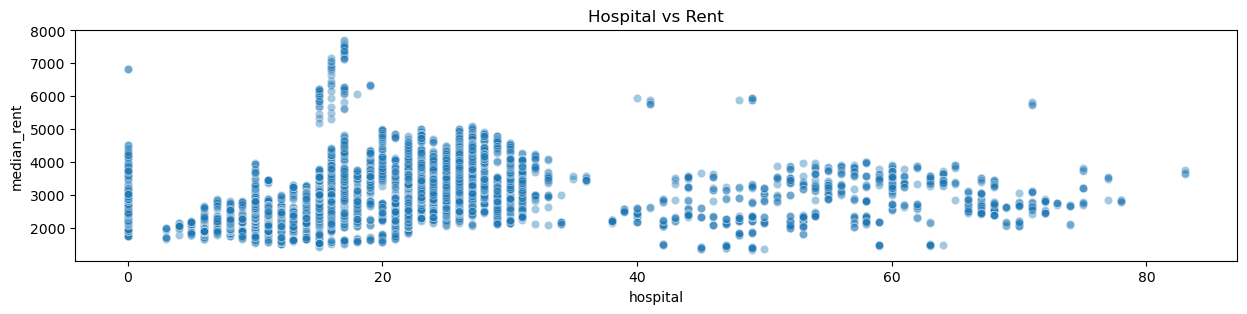

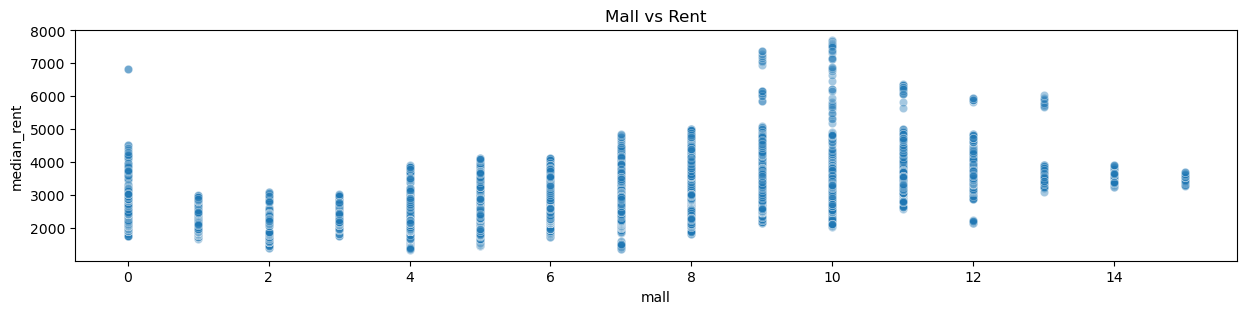

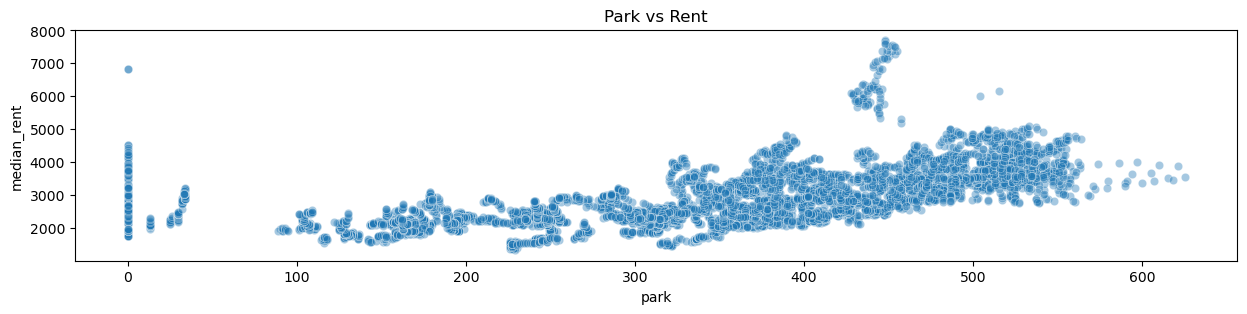

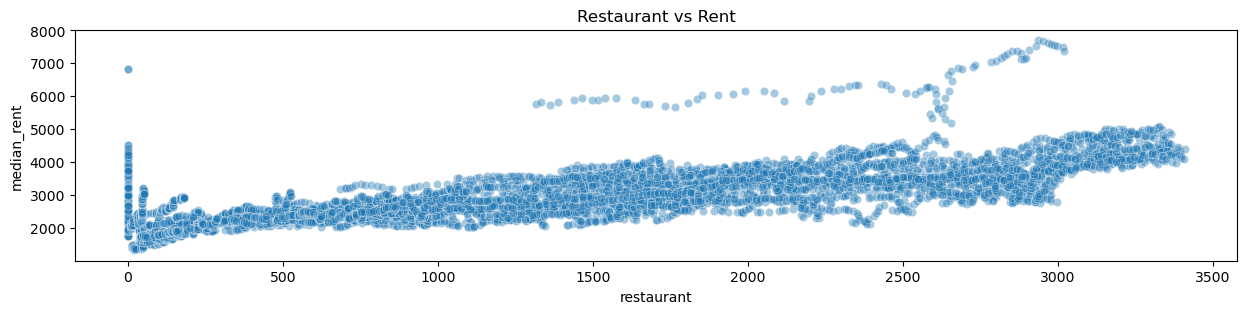

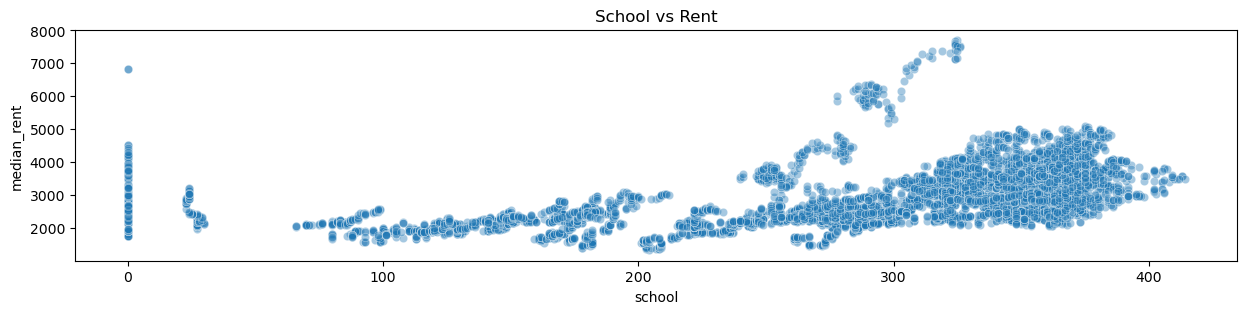

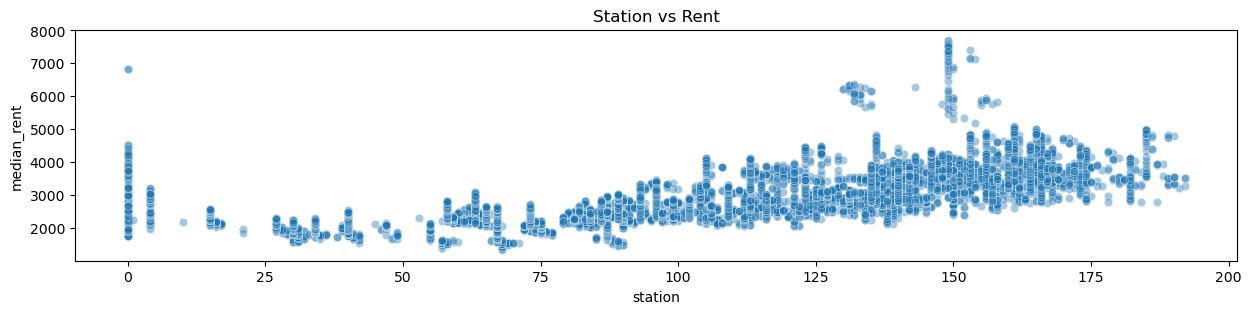

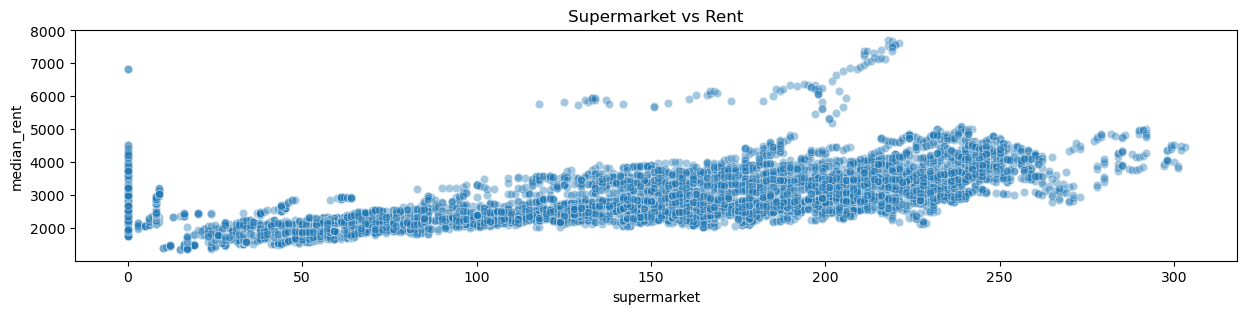

In [103]:
# Create a separate dataset for amenities and accessibility
poi_dataset = house_data_nyc[['date', 'zipcode', 'county',
                              'bank', 'bus', 'hospital', 'mall', 'park', 'restaurant', 'school', 'station', 'supermarket',
                              'median_rent', 'Total Population']]

# List of POIs
amenities = ['bank', 'bus', 'hospital', 'mall', 'park', 'restaurant', 'school', 'station', 'supermarket']

for col in amenities:
    plt.figure(figsize=(15,3))
    sns.scatterplot(data=poi_dataset, x=col, y="median_rent", alpha=0.4)
    plt.title(f"{col.capitalize()} vs Rent")
    plt.show()

In [106]:
## Normalize POIs per capita (to control for population size differences)
for col in amenities:
    poi_dataset[col + "_percap"] = poi_dataset[col] / (poi_dataset['Total Population'])

/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_54810/3297559892.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset[col + "_percap"] = poi_dataset[col] / (poi_dataset['Total Population'])


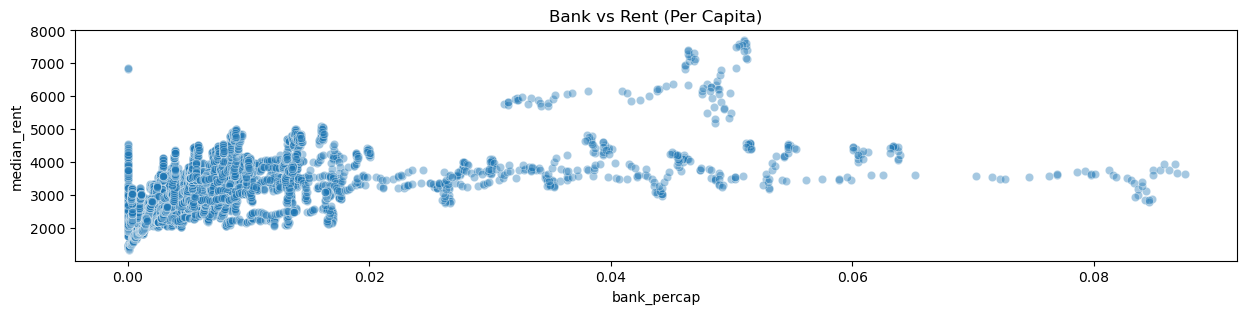

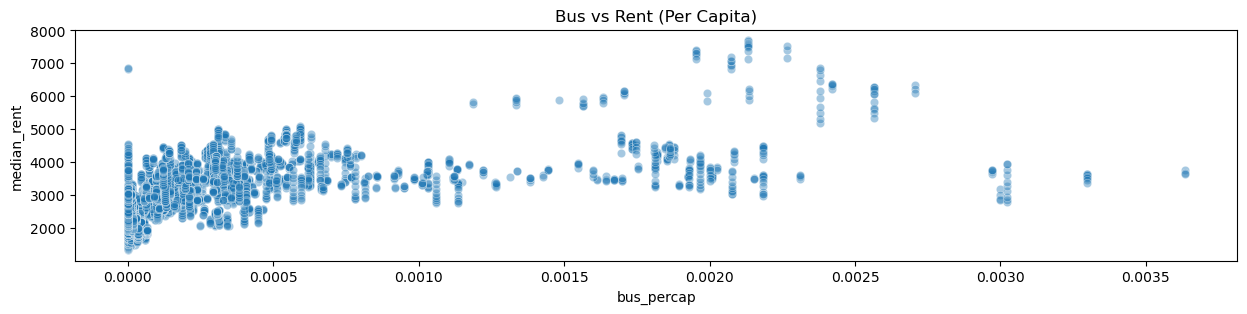

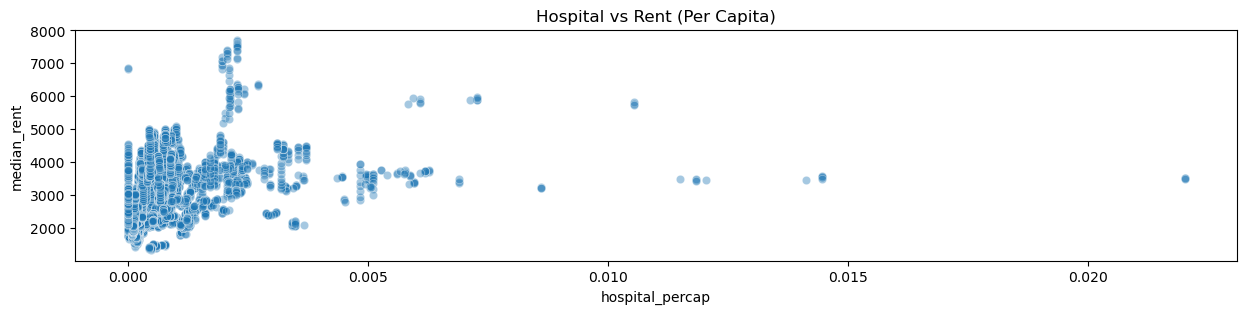

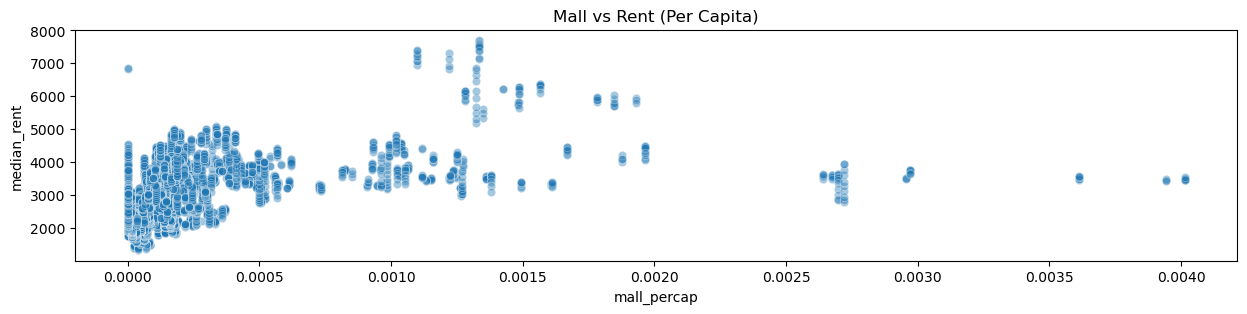

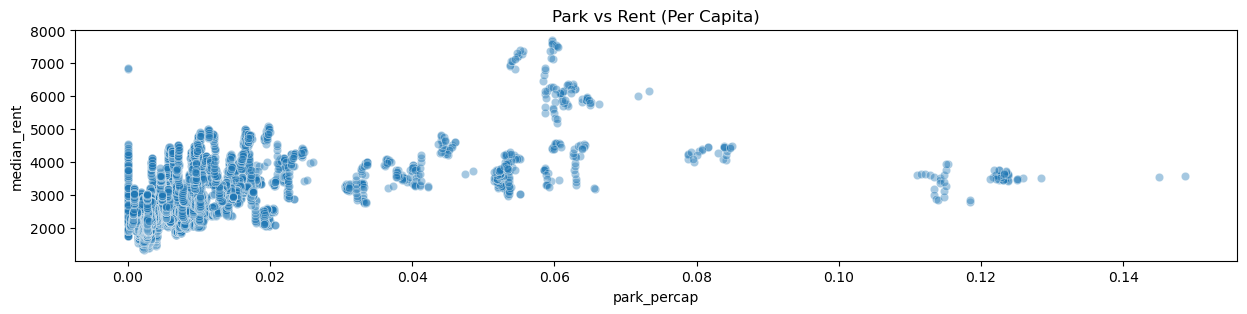

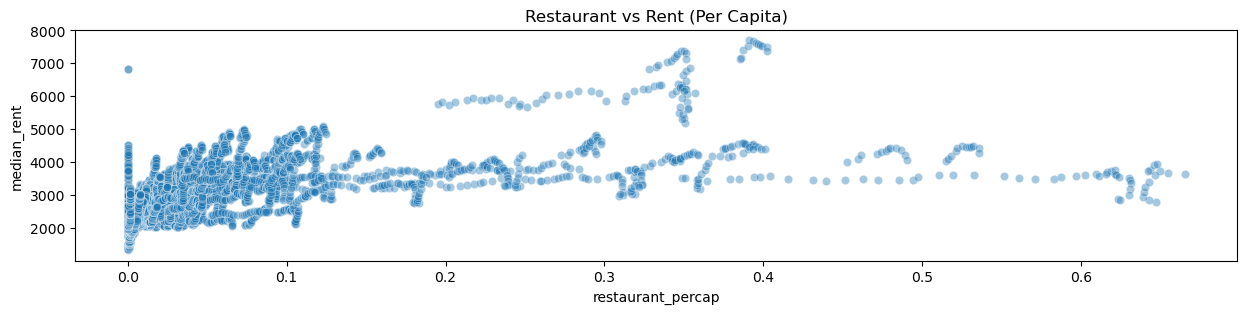

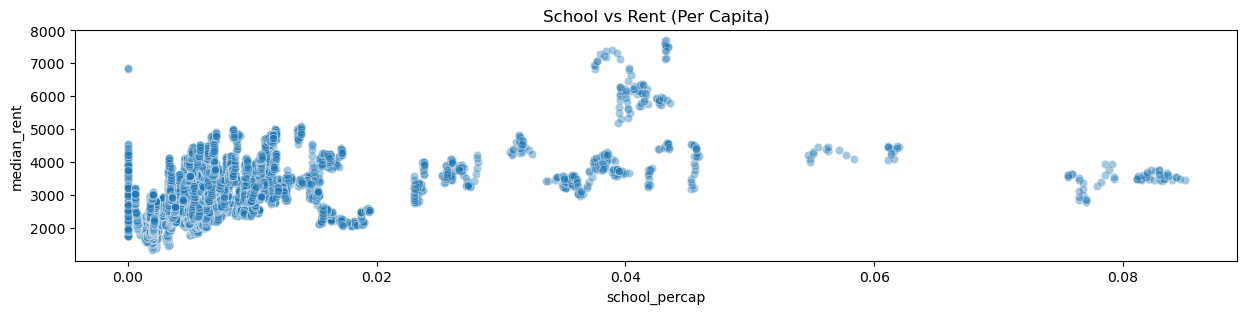

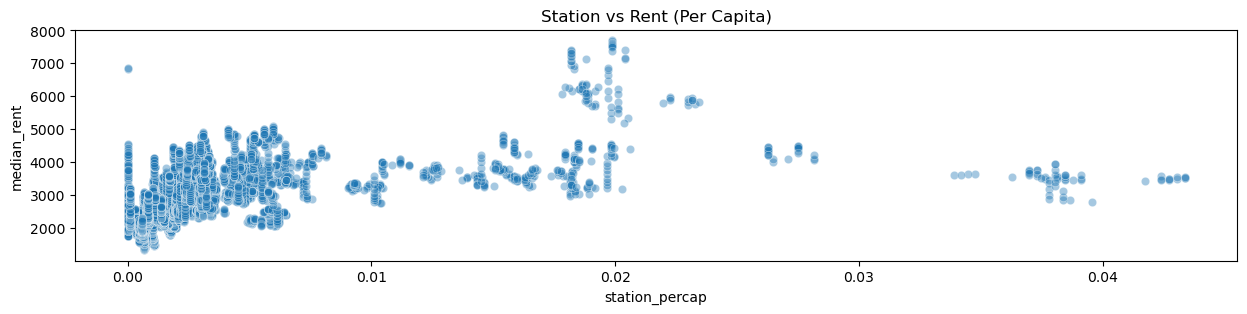

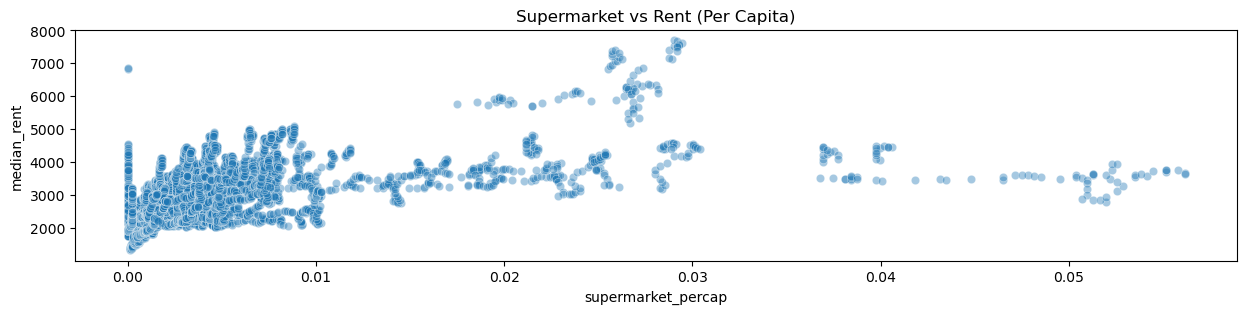

In [111]:
## Plot per capita plots
for col in amenities:
    plt.figure(figsize=(15,3))
    sns.scatterplot(data=poi_dataset, x=f"{col}_percap", y="median_rent", alpha=0.4)
    plt.title(f"{col.capitalize()} vs Rent (Per Capita)")
    plt.show()

In [113]:
# There is still a lot of noise in the plots, so let's use log transformation
for col in amenities:
    poi_dataset[col + "_log"] = np.log1p(poi_dataset[col])  # log(1+x) transformation

/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_54810/2818770350.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset[col + "_log"] = np.log1p(poi_dataset[col])  # log(1+x) transformation
/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_54810/2818770350.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset[col + "_log"] = np.log1p(poi_dataset[col])  # log(1+x) transformation
/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_54810/2818770350.py:3: SettingWit

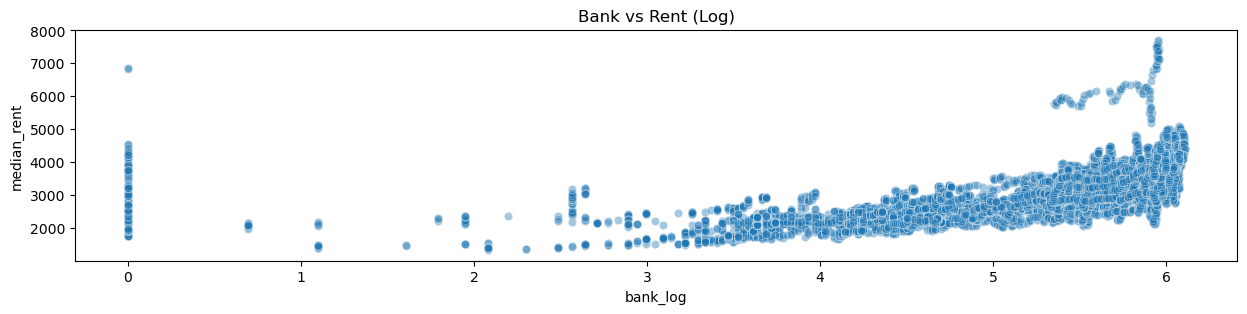

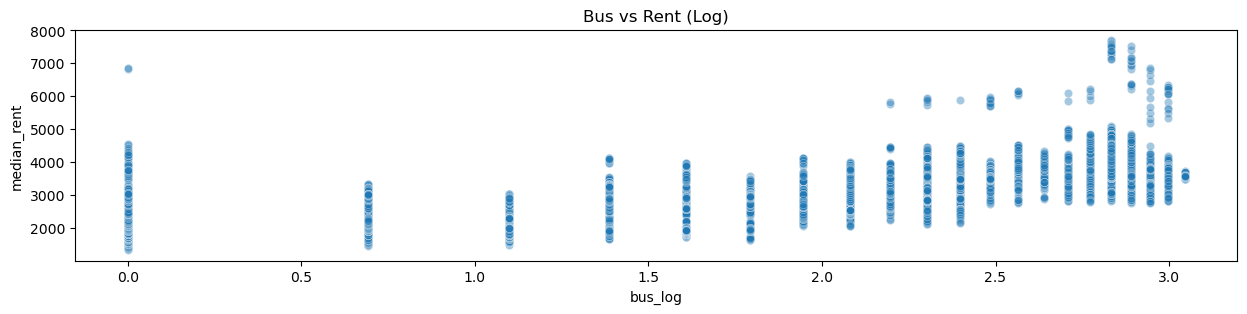

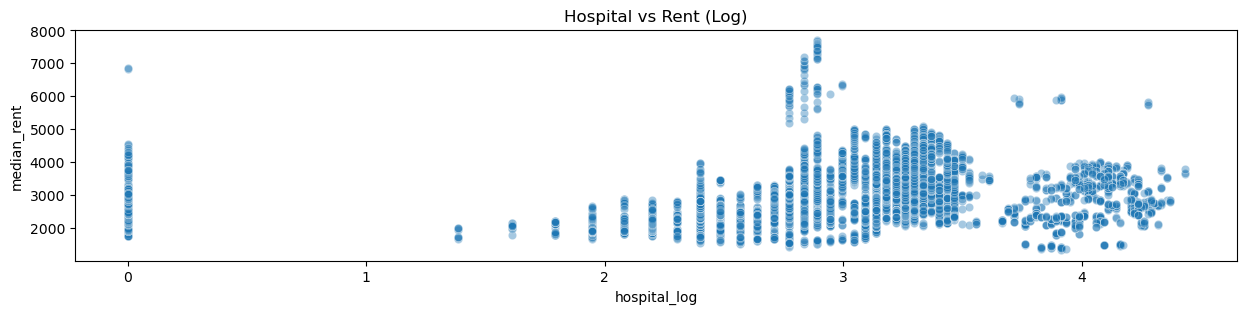

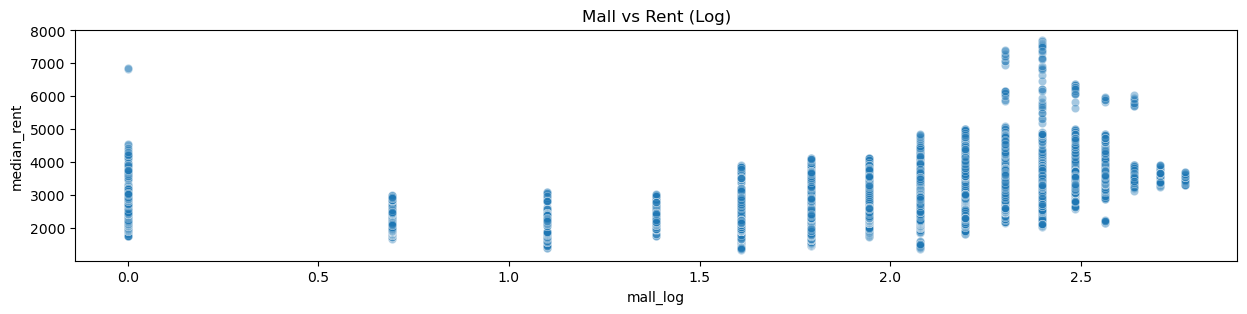

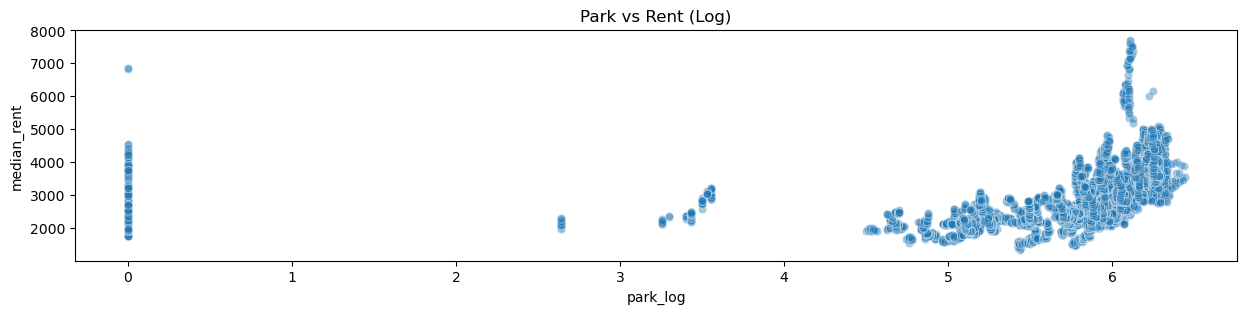

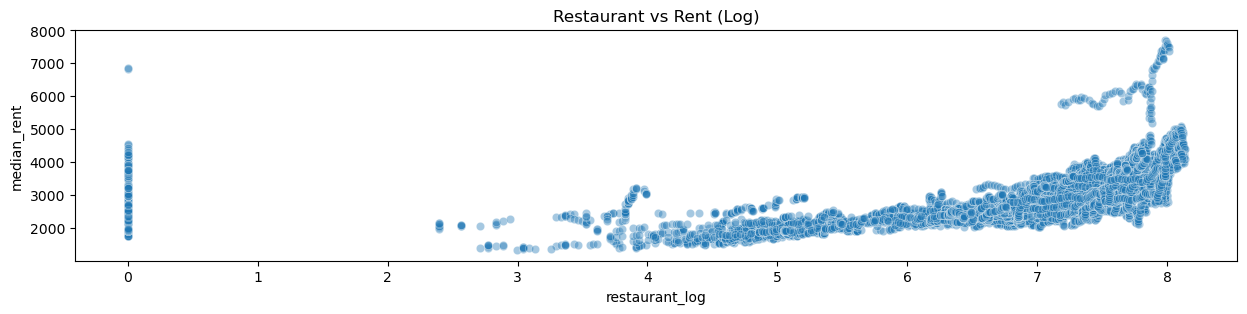

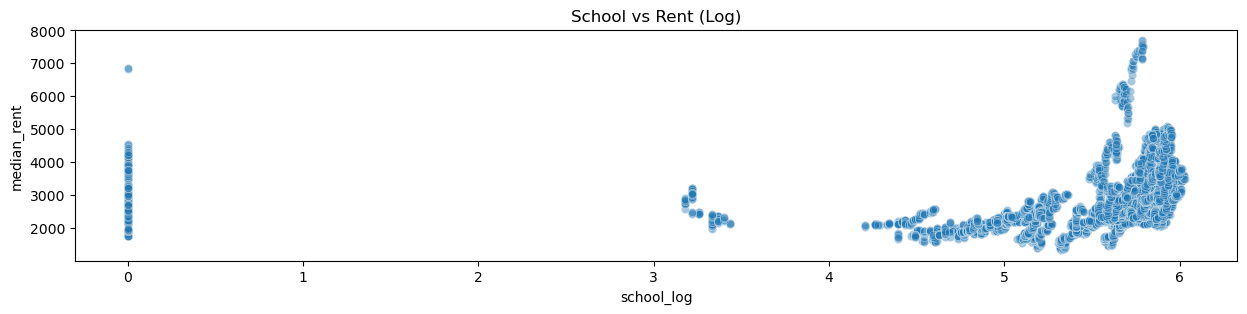

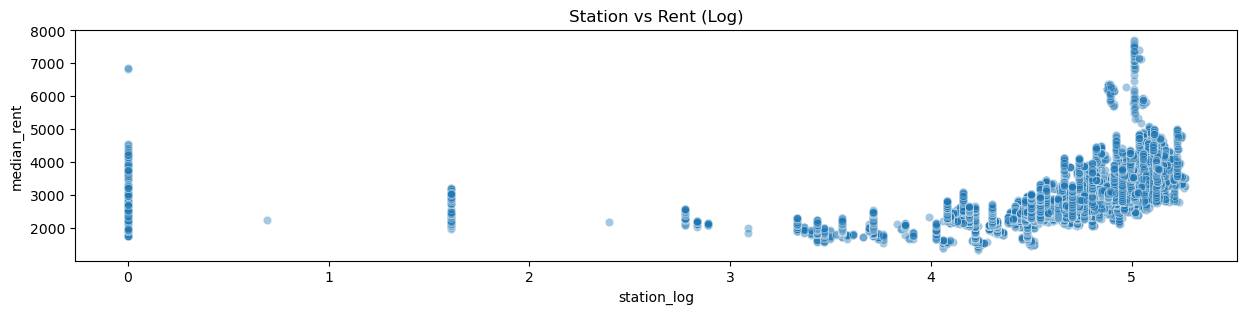

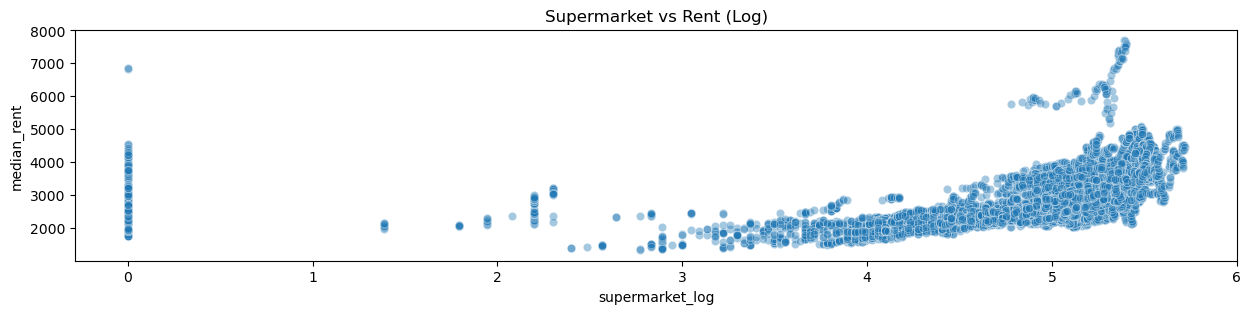

In [115]:
## Plot per log plots
for col in amenities:
    plt.figure(figsize=(15,3))
    sns.scatterplot(data=poi_dataset, x=f"{col}_log", y="median_rent", alpha=0.4)
    plt.title(f"{col.capitalize()} vs Rent (Log)")
    plt.show()

### Plot an amenity index (to assess how important (or not) amenities are for rents)

In [116]:
poi_dataset.head(2)

,date,zipcode,county,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,median_rent,Total Population,bank_percap,bus_percap,hospital_percap,mall_percap,park_percap,restaurant_percap,school_percap,station_percap,supermarket_percap,bank_log,bus_log,hospital_log,mall_log,park_log,restaurant_log,school_log,station_log,supermarket_log
0,2017-01-31,10001,New York County,258.0,8.0,56.0,10.0,515.0,1450.0,385.0,174.0,135.0,3922.292665,23332.0,0.011058,0.000343,0.0024,0.000429,0.022073,0.062146,0.016501,0.007458,0.005786,5.556828,2.197225,4.043051,2.397895,6.246107,7.280008,5.955837,5.164786,4.912655
1,2017-02-28,10001,New York County,259.0,8.0,56.0,10.0,511.0,1468.0,387.0,175.0,142.0,3863.891996,23332.0,0.011101,0.000343,0.0024,0.000429,0.021901,0.062918,0.016587,0.007500,0.006086,5.560682,2.197225,4.043051,2.397895,6.238325,7.292337,5.961005,5.170484,4.962845


/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_54810/2227947321.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset["amenity_index"] = poi_dataset[[c+"_percap" for c in amenities]].mean(axis=1)


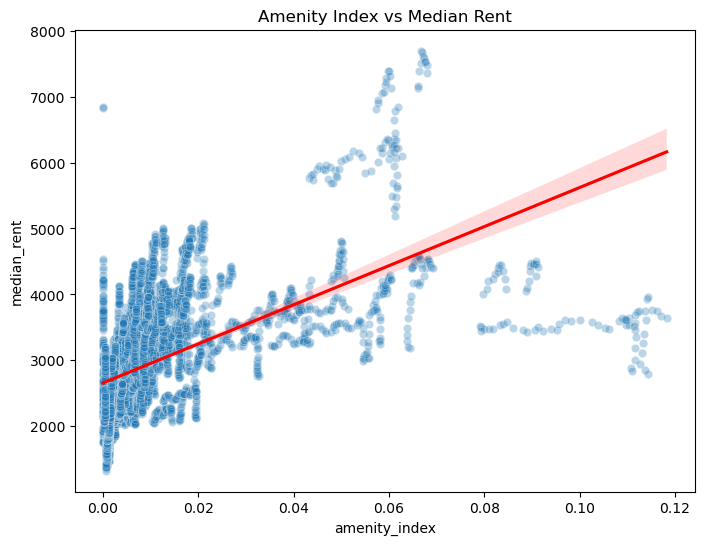

In [ ]:
# Amenity Index = simple average of per-capita POIs (this will provide some directional intuition towards the imprtance of amenities)
poi_dataset["amenity_index"] = poi_dataset[[c+"_percap" for c in amenities]].mean(axis=1)
plt.figure(figsize=(8,6))
sns.scatterplot(x="amenity_index", y="median_rent", data=poi_dataset, alpha=0.3)
sns.regplot(x="amenity_index", y="median_rent", data=poi_dataset, scatter=False, color="red")
plt.title("Amenity Index vs Median Rent")
plt.show()

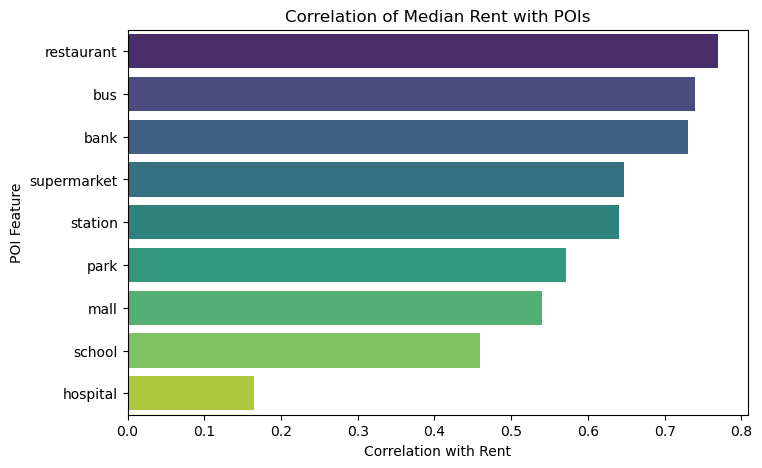

In [120]:
# Calculate correlations with rent
corrs = poi_dataset[amenities + ["median_rent"]].corr()["median_rent"].drop("median_rent")

# Sort for nicer display
corrs = corrs.sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=corrs.values, y=corrs.index, palette="viridis")

plt.title("Correlation of Median Rent with POIs")
plt.xlabel("Correlation with Rent")
plt.ylabel("POI Feature")
plt.show()

### What's the repltionship between the median rent and median home value?

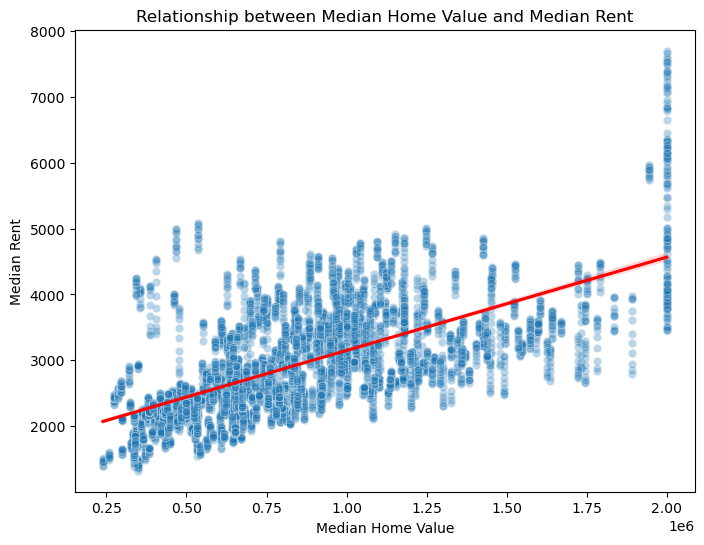

In [122]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Median Home Value", y="median_rent", data=house_data_nyc, alpha=0.3)
sns.regplot(x="Median Home Value", y="median_rent", data=house_data_nyc, scatter=False, color="red")
plt.title("Relationship between Median Home Value and Median Rent")
plt.xlabel("Median Home Value")
plt.ylabel("Median Rent")
plt.show()

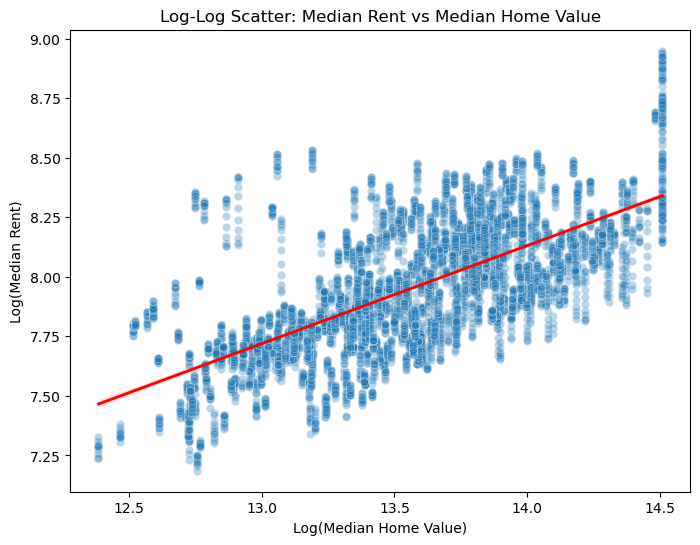

In [124]:
# Drop rows with missing or zero values to avoid log errors
df_log = house_data_nyc[(house_data_nyc["median_rent"] > 0) & (house_data_nyc["Median Home Value"] > 0)].copy()

# Apply log transform
df_log["log_rent"] = np.log(df_log["median_rent"])
df_log["log_home_value"] = np.log(df_log["Median Home Value"])

# Scatterplot with regression line
plt.figure(figsize=(8,6))
sns.scatterplot(x="log_home_value", y="log_rent", data=df_log, alpha=0.3)
sns.regplot(x="log_home_value", y="log_rent", data=df_log,
            scatter=False, color="red", line_kws={"lw":2})

plt.title("Log-Log Scatter: Median Rent vs Median Home Value")
plt.xlabel("Log(Median Home Value)")
plt.ylabel("Log(Median Rent)")
plt.show()

### Aggregate data at an annual level and calculate the rent to price ratio

In [127]:
# Compute annual rent as sum of 12 monthly rents per ZIP-year
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
annual_rent = (
    house_data_nyc.groupby(["zipcode","year"])["median_rent"].sum()
    .reset_index()
    .rename(columns={"median_rent":"annual_rent"})
)

# Get annual median home value (e.g., December value or yearly median)
annual_home_value = (
    house_data_nyc.groupby(["zipcode","year"])["Median Home Value"].median()
    .reset_index()
    .rename(columns={"Median Home Value":"annual_home_value"})
)

# Merge
annual_metrics = pd.merge(annual_rent, annual_home_value, on=["zipcode","year"])

# Rent-to-Price Ratio
annual_metrics["rent_to_price_ratio"] = annual_metrics["annual_rent"] / annual_metrics["annual_home_value"]

# Add scaled values
annual_metrics[['annual_rent_scaled', 'annual_home_val_scaled']] = scaler.fit_transform(annual_metrics[["annual_rent", "annual_home_value"]])
annual_metrics.head()

,zipcode,year,annual_rent,annual_home_value,rent_to_price_ratio,annual_rent_scaled,annual_home_val_scaled
0,10001,2017,47192.594440,460500.0,0.102481,0.423211,0.125781
1,10001,2018,47819.593116,355600.0,0.134476,0.431713,0.066212
2,10001,2019,49610.755162,343400.0,0.144469,0.455999,0.059284
3,10001,2020,45806.055875,386800.0,0.118423,0.404410,0.083930
4,10001,2021,48344.818528,403800.0,0.119725,0.438834,0.093583


/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


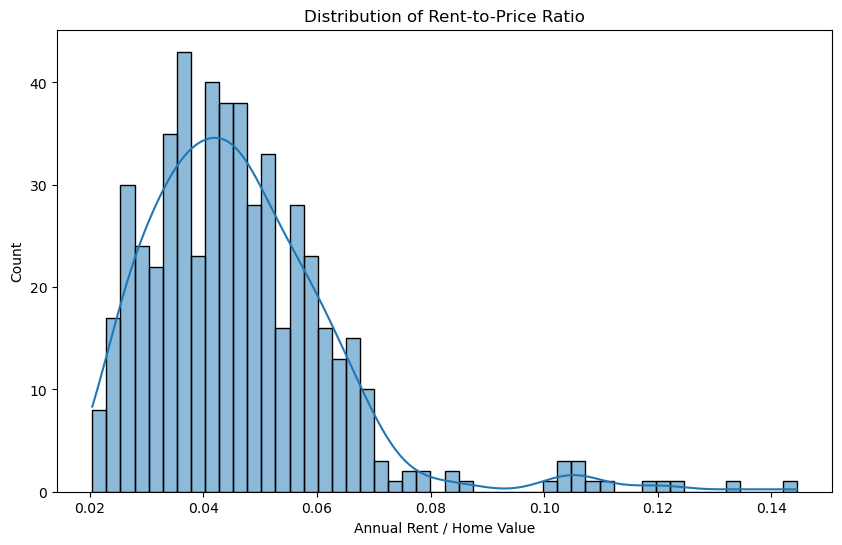

In [128]:
plt.figure(figsize=(10,6))
sns.histplot(annual_metrics["rent_to_price_ratio"], bins=50, kde=True)
plt.title("Distribution of Rent-to-Price Ratio")
plt.xlabel("Annual Rent / Home Value")
plt.show()

<Axes: xlabel='annual_rent_scaled', ylabel='annual_home_val_scaled'>

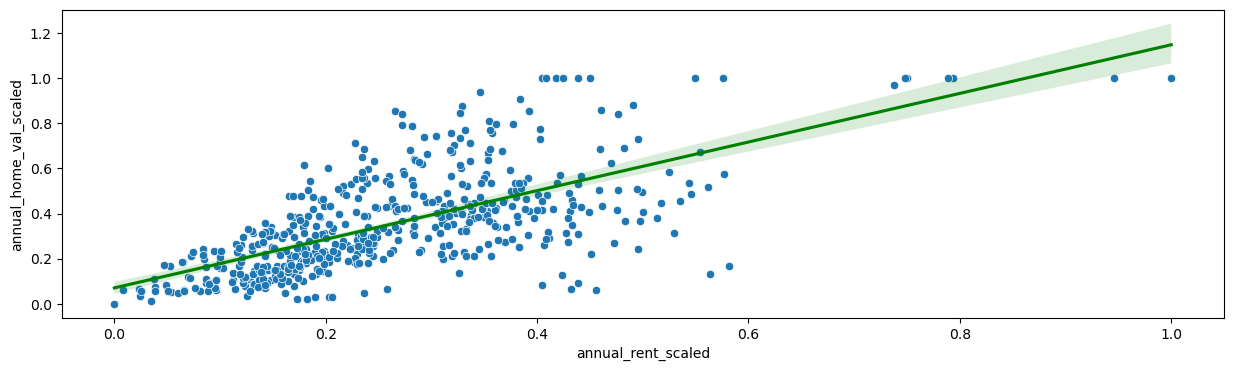

In [135]:
# Plot a scatterplot
plt.figure(figsize=(15,4))
sns.scatterplot(data=annual_metrics, x='annual_rent_scaled', y='annual_home_val_scaled')
sns.regplot(data=annual_metrics, x='annual_rent_scaled', y='annual_home_val_scaled', scatter=False, color="green")

## Phase 3: Rent and Affordability Prediction Models and Time Series Analysis

### Forecasting Readiness

    Create stationarity plots for rents.

    Seasonal decomposition.

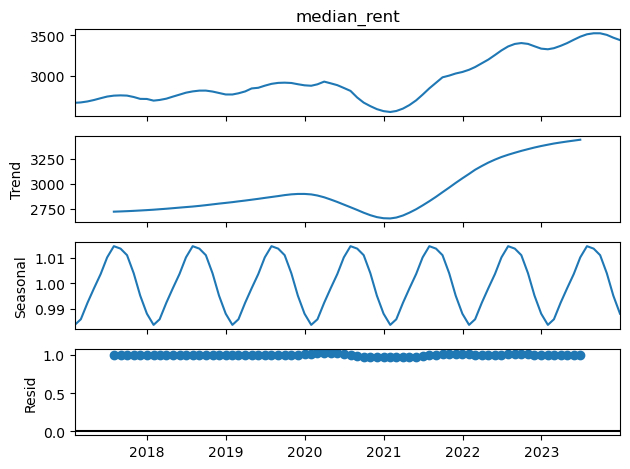

In [142]:
from statsmodels.tsa.seasonal import seasonal_decompose

nyc_rent_series = ny_house.groupby("date")['median_rent'].mean()
result = seasonal_decompose(nyc_rent_series, model="multiplicative", period=12)
result.plot()
plt.show()

### Perform PCA and identify the most suitable variables for the prediction model

In [137]:
# Create a new dataset for PCA analysis
pca_dataset = house_data_nyc.copy()

In [138]:
# guard against missing values (HouseTS already imputes, but just in case)
pca_dataset[amenities] = pca_dataset[amenities].fillna(0)

In [143]:
# per-capita (per 1,000 residents to keep values readable)
for c in amenities:
    pca_dataset[f"{c}_percap"] = 1000.0 * pca_dataset[c] / pca_dataset["Total Population"]

# log1p to reduce skew (on per-capita, not raw)
percap_cols = [f"{c}_percap" for c in amenities]
pca_dataset[[f"{c}_log" for c in percap_cols]] = np.log1p(pca_dataset[percap_cols])
log_cols = [f"{c}_log" for c in percap_cols]

In [145]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- EDA mode: fit on all data (simple) ---
X = pca_dataset[log_cols].to_numpy()
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

pca = PCA(n_components=None, random_state=42)
X_pca = pca.fit_transform(Xz)

In [146]:
# store explained variance to choose components
expl_var = pca.explained_variance_ratio_.round(4)
cum_expl = expl_var.cumsum().round(4)
expl_var, cum_expl[:5]  # peek

(array([0.892 , 0.0528, 0.0311, 0.0112, 0.006 , 0.0026, 0.0021, 0.0013,
        0.0009]),
 array([0.892 , 0.9448, 0.9759, 0.9871, 0.9931]))

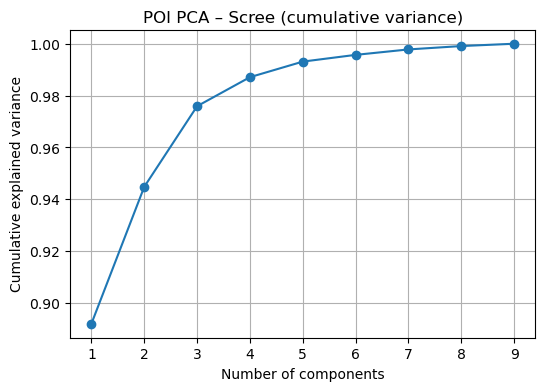

Chosen components (≈90% var): 2


In [147]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(expl_var)+1), cum_expl, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("POI PCA – Scree (cumulative variance)")
plt.grid(True)
plt.show()

# choose smallest K that gets you to ~90% variance
K = int(np.argmax(cum_expl >= 0.90) + 1)
print("Chosen components (≈90% var):", K)